Purpose: See if titratable acidity data correspond to physiological categories established for Yg genotypes using LICOR data.<br>
Author: Anna Pardo<br>
Date initiated: Apr. 14, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

## Section 1: Data wrangling

In [2]:
# load titratable acidity data
ta = pd.read_csv("/home/leviathan22/Yucca_genomics/All_titrations_raw.csv",sep=",",header="infer")
ta.head()

,Sample,Rep,Date,Time,Month,genotype,specific,initial pH,titrated ul 6.5,titrated ul 7.0,H+ uq/g
0,66,1,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.96,926,2026,54.75675676
1,66,2,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.77,1100,2200,55.97964377
2,66,3,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.52,NaN,2400,76.31160572
3,67,1,42957.0,D1PM,17-Aug,61,61.2.0.2015,4.74,3600,4520,100.8928571
4,67,2,42957.0,D1PM,17-Aug,61,61.2.0.2015,6.18,800,2800,58.27263267


In [3]:
# load physiological classifications
phys = json.load(open("/home/leviathan22/Yucca_genomics/phys_figures/physiological_CAM_categories.json"))

In [4]:
ta["genotype"].unique()

array(['61', '70', '55', '51', '16', '56', '12', '52', '53', '36', '48',
       '37', '43', '46', 'Eudy', '15', '20', 'G', '19', '13', '45', '1AB',
       '18', '2AB', 'Eudy3', 'Eudy1', 'Eudy4', 'Eudy2'], dtype=object)

In [5]:
# reformat 'extra' Eudys
gtmap = {}
for g in ta["genotype"].unique():
    if len(g)==5:
        gtmap[g] = "Eudy"
    else:
        gtmap[g] = g

In [6]:
ta["genotype"] = ta["genotype"].map(gtmap)
ta["genotype"].unique()

array(['61', '70', '55', '51', '16', '56', '12', '52', '53', '36', '48',
       '37', '43', '46', 'Eudy', '15', '20', 'G', '19', '13', '45', '1AB',
       '18', '2AB'], dtype=object)

In [7]:
ta["Time"].unique()

array(['D1PM', 'D1AM', 'D7PM', 'D7AM', 'D9AM', 'D9PM'], dtype=object)

In [8]:
# load TA for Ya (Yf is irrelevant, all values 0)
yata = pd.read_csv("/home/leviathan22/Yucca_genomics/YA_TA.csv",sep=",",header="infer")

In [9]:
for c in yata.columns:
    yata.rename(columns={c:c.strip()},inplace=True)

In [10]:
yata.rename(columns={"umol_NaOH_per_g":"H+ uq/g"},inplace=True)

In [11]:
yata.head()

,Genotype,Time,Treatment,Weight_g,pH_start,ul_pH6.5,ul_pH7.0,Total_ul,ul_per_mg,umol_NaOH_per_mg,H+ uq/g
0,YA17,3,W,0.0968,7.34,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,YA17,6,W,0.1240,5.10,7910.0,1350.0,9260.0,74.677419,0.149355,149.354839
2,YA17,6,D,0.0601,6.82,0.0,320.0,320.0,5.324459,0.010649,10.648918
3,YA17,3,D,0.1051,7.16,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,YA23,6,W,0.0942,4.89,8850.0,1560.0,10410.0,110.509554,0.221019,221.019108


In [12]:
ta.head()

,Sample,Rep,Date,Time,Month,genotype,specific,initial pH,titrated ul 6.5,titrated ul 7.0,H+ uq/g
0,66,1,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.96,926,2026,54.75675676
1,66,2,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.77,1100,2200,55.97964377
2,66,3,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.52,NaN,2400,76.31160572
3,67,1,42957.0,D1PM,17-Aug,61,61.2.0.2015,4.74,3600,4520,100.8928571
4,67,2,42957.0,D1PM,17-Aug,61,61.2.0.2015,6.18,800,2800,58.27263267


In [13]:
# for titratable acidity, we care most about the difference between AM and PM (overnight accumulation, if positive)
## calculate the difference of means (of replicates) for each sample between AM & PM for a given D (1, 7, 9) time point
## D1=Watered, D7=Drought, D9=recovery

# split the Time column for Yg data
treat = {}
for i in ta["Time"].unique():
    if i.startswith("D1"):
        treat[i] = "W"
    elif i.startswith("D7"):
        treat[i] = "D"
    else:
        treat[i] = "R"

In [14]:
ta["Treatment"] = ta["Time"].map(treat)
ta.head()

,Sample,Rep,Date,Time,Month,genotype,specific,initial pH,titrated ul 6.5,titrated ul 7.0,H+ uq/g,Treatment
0,66,1,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.96,926,2026,54.75675676,W
1,66,2,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.77,1100,2200,55.97964377,W
2,66,3,42957.0,D1PM,17-Aug,61,61.1.3.2016,5.52,NaN,2400,76.31160572,W
3,67,1,42957.0,D1PM,17-Aug,61,61.2.0.2015,4.74,3600,4520,100.8928571,W
4,67,2,42957.0,D1PM,17-Aug,61,61.2.0.2015,6.18,800,2800,58.27263267,W


In [15]:
yata["Treatment"].unique()

array(['W', 'D'], dtype=object)

In [16]:
time = {}
for i in ta["Time"].unique():
    if i.endswith("PM"):
        time[i] = "PM"
    else:
        time[i] = "AM"
ta["Time"] = ta["Time"].map(time)
ta.head()

,Sample,Rep,Date,Time,Month,genotype,specific,initial pH,titrated ul 6.5,titrated ul 7.0,H+ uq/g,Treatment
0,66,1,42957.0,PM,17-Aug,61,61.1.3.2016,5.96,926,2026,54.75675676,W
1,66,2,42957.0,PM,17-Aug,61,61.1.3.2016,5.77,1100,2200,55.97964377,W
2,66,3,42957.0,PM,17-Aug,61,61.1.3.2016,5.52,NaN,2400,76.31160572,W
3,67,1,42957.0,PM,17-Aug,61,61.2.0.2015,4.74,3600,4520,100.8928571,W
4,67,2,42957.0,PM,17-Aug,61,61.2.0.2015,6.18,800,2800,58.27263267,W


In [17]:
yata["Time"].unique()

array([3, 6])

In [18]:
yata["Time"] = yata["Time"].map({3:"PM",6:"AM"})
yata.head()

,Genotype,Time,Treatment,Weight_g,pH_start,ul_pH6.5,ul_pH7.0,Total_ul,ul_per_mg,umol_NaOH_per_mg,H+ uq/g
0,YA17,PM,W,0.0968,7.34,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,YA17,AM,W,0.1240,5.10,7910.0,1350.0,9260.0,74.677419,0.149355,149.354839
2,YA17,AM,D,0.0601,6.82,0.0,320.0,320.0,5.324459,0.010649,10.648918
3,YA17,PM,D,0.1051,7.16,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,YA23,AM,W,0.0942,4.89,8850.0,1560.0,10410.0,110.509554,0.221019,221.019108


In [19]:
# put all data together after adding species cols
yata["species"] = "Ya"
ta["species"] = "Yg"

In [20]:
ta.rename(columns={"genotype":"Genotype"},inplace=True)

In [21]:
yata["Genotype"] = "Ya"

In [22]:
allta = pd.concat([yata[["species","Genotype","Time","Treatment","H+ uq/g"]],
                   ta[["species","Genotype","Time","Treatment","H+ uq/g"]]])
allta.head()

,species,Genotype,Time,Treatment,H+ uq/g
0,Ya,Ya,PM,W,0.0
1,Ya,Ya,AM,W,149.354839
2,Ya,Ya,AM,D,10.648918
3,Ya,Ya,PM,D,0.0
4,Ya,Ya,AM,W,221.019108


## Section 2: Delta calculation & plotting

In [23]:
# function to calculate delta for a given genotype 
def calc_ta_delta(gt,df=allta):
    gtdf = df[df["Genotype"]==gt]
    gtdf["H+ uq/g"] = pd.to_numeric(gtdf["H+ uq/g"], errors="coerce")
    means = gtdf.groupby(["Treatment","Time"]).mean().reset_index()
    if "R" in list(means["Treatment"].unique()):
        means = means[means["Treatment"]!="R"]
    ## compute standard deviation
    #if not gt.startswith("YA"):
    #    sd = gtdf.drop("species",axis=1).groupby(["Treatment","Time"]).std().reset_index()
        # count sample sizes
    #    sampsize = gtdf.drop("species",axis=1).groupby(["Treatment","Time"]).count().reset_index()
    #else:
    sd = gtdf.drop(["species","Genotype"],axis=1).groupby(["Treatment","Time"]).std().reset_index()
    # count sample sizes
    sampsize = gtdf.drop(["species","Genotype"],axis=1).groupby(["Treatment","Time"]).count().reset_index()
    # calculate AM minus PM delta for each treatment
    #if "Genotype" in means.columns:
    #    widemeans = means.pivot(index="Treatment",columns="Time",values="Genotype").reset_index()
    #elif "H+ uq/g" in means.columns:
    widemeans = means.pivot(index="Treatment",columns="Time",values="H+ uq/g").reset_index()
    sdwide = sd.pivot(index="Treatment",columns="Time",values="H+ uq/g").reset_index().rename(columns={
        "AM":"AM_sd","PM":"PM_sd"
    })
    sswide = sampsize.pivot(index="Treatment",columns="Time",values="H+ uq/g").reset_index().rename(columns={
        "AM":"AM_n","PM":"PM_n"
    })
    widemeans["Accumulation_uq/g"] = widemeans["AM"]-widemeans["PM"]
    widemeans["Genotype"] = gt
    widemeans["Species"] = gtdf["species"].unique()[0]
    # compute SE of difference of means
    widemeans["SE_delta"] = np.sqrt((sdwide["AM_sd"]**2/sswide["AM_n"])+(sdwide["PM_sd"]**2/sswide["PM_n"]))
    # fill NAs for any genotypes (mostly Ya) without replication
    widemeans["SE_delta"].fillna(0,inplace=True)
    
    return widemeans

In [24]:
calc_ta_delta("18")

/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtdf["H+ uq/g"] = pd.to_numeric(gtdf["H+ uq/g"], errors="coerce")


Time,Treatment,AM,PM,Accumulation_uq/g,Genotype,Species,SE_delta
0,D,56.448837,21.359885,35.088952,18,Yg,2.607213
1,W,50.655595,12.247906,38.407690,18,Yg,3.590659


In [25]:
# do this across genotypes
dflist = []
for g in allta["Genotype"].unique():
    print(g)
    dflist.append(calc_ta_delta(g))
deltas = pd.concat(dflist)
deltas.head()

/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtdf["H+ uq/g"] = pd.to_numeric(gtdf["H+ uq/g"], errors="coerce")
/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtdf["H+ uq/g"] = pd.to_numeric(gtdf["H+ uq/g"], errors="coerce")
/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

Ya
61
70
55
51
16
56
12
52
53
36
48
37
43
46
Eudy
15
20


/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtdf["H+ uq/g"] = pd.to_numeric(gtdf["H+ uq/g"], errors="coerce")
/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtdf["H+ uq/g"] = pd.to_numeric(gtdf["H+ uq/g"], errors="coerce")
/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

G
19
13
45
1AB
18
2AB


/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtdf["H+ uq/g"] = pd.to_numeric(gtdf["H+ uq/g"], errors="coerce")
/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtdf["H+ uq/g"] = pd.to_numeric(gtdf["H+ uq/g"], errors="coerce")
/tmp/ipykernel_15900/2210381962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

Time,Treatment,AM,PM,Accumulation_uq/g,Genotype,Species,SE_delta
0,D,80.200771,0.000000,80.200771,Ya,Ya,30.927038
1,W,211.006314,0.000000,211.006314,Ya,Ya,20.475401
0,D,137.405116,10.714069,126.691047,61,Yg,25.831723
1,W,74.261394,108.679618,-34.418224,61,Yg,16.439574
0,D,159.880694,14.012426,145.868267,70,Yg,33.357731


In [26]:
len(deltas["Genotype"].unique())

25

In [27]:
deltas["Genotype"].unique()

array(['Ya', '61', '70', '55', '51', '16', '56', '12', '52', '53', '36',
       '48', '37', '43', '46', 'Eudy', '15', '20', 'G', '19', '13', '45',
       '1AB', '18', '2AB'], dtype=object)

In [28]:
# create a custom palette for plotting - should match that used for LICOR physiology
## EXCEPT note genotypes 12 & 20 did not have LICOR data
custompal = {
    "36":"darkgreen",
    "37":"royalblue",
    "70":"firebrick",
    "61":"saddlebrown",
    "55":"darkslategrey",
    "51":"rebeccapurple",
    "52":"lawngreen",
    "16":"darkgoldenrod",
    "56":"deeppink",
    "53":"peru",
    "48":"turquoise",
    "43":"orchid",
    "G":"lightcoral",
    "45":"skyblue",
    "19":"mediumseagreen",
    "13":"tan",
    "Eudy":"olive",
    "46":"gray",
    "15":"orangered",
    "2AB":"sandybrown",
    "1AB":"olivedrab",
    "18":"mediumslateblue",
    "Ya":"gold",
    "12":"cadetblue",
    "20":"midnightblue"
}

In [29]:
deltas.head()

Time,Treatment,AM,PM,Accumulation_uq/g,Genotype,Species,SE_delta
0,D,80.200771,0.000000,80.200771,Ya,Ya,30.927038
1,W,211.006314,0.000000,211.006314,Ya,Ya,20.475401
0,D,137.405116,10.714069,126.691047,61,Yg,25.831723
1,W,74.261394,108.679618,-34.418224,61,Yg,16.439574
0,D,159.880694,14.012426,145.868267,70,Yg,33.357731


In [30]:
# separate drought & watered data into different columns
ddelt = deltas[deltas["Treatment"]=="D"]
wdelt = deltas[deltas["Treatment"]=="W"]

In [31]:
ddelt.rename(columns={"Accumulation_uq/g":"Accumulation_D","SE_delta":"SE_D"},inplace=True)
wdelt.rename(columns={"Accumulation_uq/g":"Accumulation_W","SE_delta":"SE_W"},inplace=True)

/tmp/ipykernel_15900/2515652261.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ddelt.rename(columns={"Accumulation_uq/g":"Accumulation_D","SE_delta":"SE_D"},inplace=True)
/tmp/ipykernel_15900/2515652261.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wdelt.rename(columns={"Accumulation_uq/g":"Accumulation_W","SE_delta":"SE_W"},inplace=True)


In [32]:
alldelt = wdelt[["Genotype","Accumulation_W","SE_W"]].merge(ddelt[["Genotype","Accumulation_D","SE_D"]])

In [33]:
alldelt.head()

Time,Genotype,Accumulation_W,SE_W,Accumulation_D,SE_D
0,Ya,211.006314,20.475401,80.200771,30.927038
1,61,-34.418224,16.439574,126.691047,25.831723
2,70,2.926478,19.889107,145.868267,33.357731
3,55,58.344058,10.357397,82.365603,6.834580
4,51,269.842835,12.381966,71.862665,10.331172


In [34]:
alldelt["color"] = alldelt["Genotype"].map(custompal)

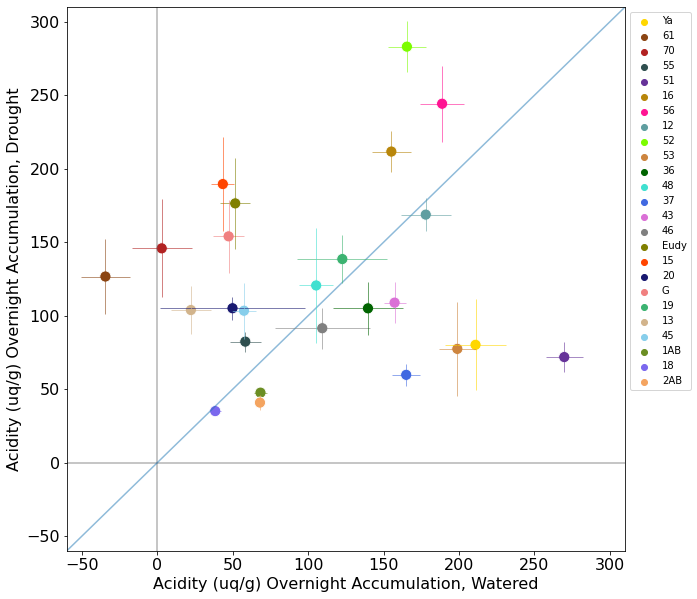

In [35]:
# plot the data
fig,ax = plt.subplots(figsize=(10,10))
ax.axvline(x=0,color="dimgray",alpha=0.5)
ax.axhline(y=0,color="dimgray",alpha=0.5)
sns.lineplot(x=np.arange(-60,311,10),y=np.arange(-60,311,10),color="tab:blue",alpha=0.5)
sns.scatterplot(data=alldelt,x="Accumulation_W",y="Accumulation_D",hue="Genotype",palette=custompal,s=125)
#ax.axvline(x=0,color="dimgray")
plt.errorbar(alldelt["Accumulation_W"],alldelt["Accumulation_D"],xerr=alldelt["SE_W"],yerr=alldelt["SE_D"],
              fmt="o",alpha=0.75,ecolor=alldelt["color"],markersize=0,elinewidth=0.75)
ax.tick_params(which="both",labelsize=16)
ax.set_xlim(-60,310)
ax.set_ylim(-60,310)
ax.legend(bbox_to_anchor=(1,1))
plt.xlabel("Acidity (uq/g) Overnight Accumulation, Watered",fontsize=16)
plt.ylabel("Acidity (uq/g) Overnight Accumulation, Drought",fontsize=16)
plt.savefig("./TA_accumulation_bygenotype.png",dpi=300,bbox_inches="tight")
plt.savefig("./TA_accumulation_bygenotype.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./TA_accumulation_bygenotype.svg",dpi=300,bbox_inches="tight")

In [36]:
phys["Ya"] = "strong CAM parent"

In [37]:
alldelt["CAM physiology from LICOR"] = alldelt["Genotype"].map(phys)
alldelt["CAM physiology from LICOR"].unique()

array(['strong CAM parent', 'C3', 'possible_fac_CAM', 'facultative_CAM',
       nan], dtype=object)

In [38]:
alldelt["CAM physiology from LICOR"].fillna("no LICOR data",inplace=True)

In [39]:
alldelt["CAM physiology from LICOR"].unique()

array(['strong CAM parent', 'C3', 'possible_fac_CAM', 'facultative_CAM',
       'no LICOR data'], dtype=object)

In [40]:
cpal2 = {
    "strong CAM parent":"gold",
    "no LICOR data":"dimgrey",
    "facultative_CAM":"coral",
    "possible_fac_CAM":"saddlebrown",
    "C3":"midnightblue"
}

In [41]:
alldelt["physcolor"] = alldelt["CAM physiology from LICOR"].map(cpal2)

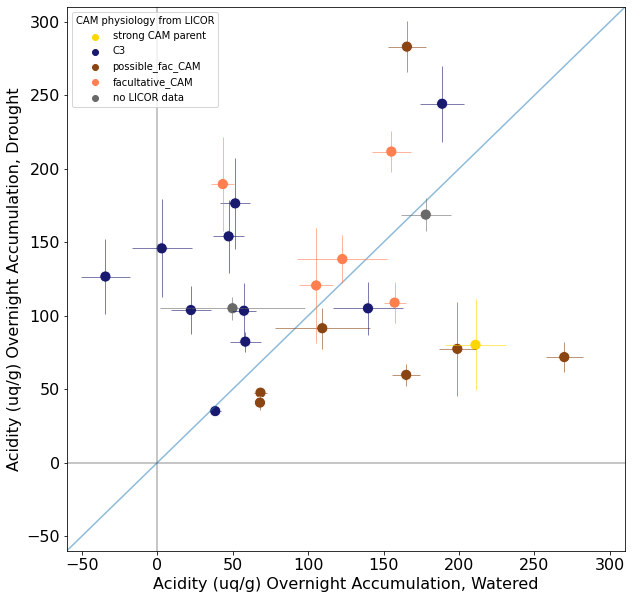

In [42]:
# plot the data by previously established physiological category (based on LICOR data)
fig,ax = plt.subplots(figsize=(10,10))
ax.axvline(x=0,color="dimgray",alpha=0.5)
ax.axhline(y=0,color="dimgray",alpha=0.5)
sns.lineplot(x=np.arange(-60,311,10),y=np.arange(-60,311,10),color="tab:blue",alpha=0.5)

sns.scatterplot(data=alldelt,x="Accumulation_W",y="Accumulation_D",hue="CAM physiology from LICOR",palette=cpal2,s=125)
plt.errorbar(alldelt["Accumulation_W"],alldelt["Accumulation_D"],xerr=alldelt["SE_W"],yerr=alldelt["SE_D"],
              fmt="o",alpha=0.75,ecolor=alldelt["physcolor"],markersize=0,elinewidth=0.75)

ax.tick_params(which="both",labelsize=16)
ax.set_xlim(-60,310)
ax.set_ylim(-60,310)
plt.xlabel("Acidity (uq/g) Overnight Accumulation, Watered",fontsize=16)
plt.ylabel("Acidity (uq/g) Overnight Accumulation, Drought",fontsize=16)
plt.savefig("./TA_accumulation_byphys.png",dpi=300,bbox_inches="tight")
plt.savefig("./TA_accumulation_byphys.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./TA_accumulation_byphys.svg",dpi=300,bbox_inches="tight")

## Section 3: T-test to determine statistical difference between treatments for each genotype

In [43]:
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection

In [44]:
allta.head()

,species,Genotype,Time,Treatment,H+ uq/g
0,Ya,Ya,PM,W,0.0
1,Ya,Ya,AM,W,149.354839
2,Ya,Ya,AM,D,10.648918
3,Ya,Ya,PM,D,0.0
4,Ya,Ya,AM,W,221.019108


In [45]:
ta.head()

,Sample,Rep,Date,Time,Month,Genotype,specific,initial pH,titrated ul 6.5,titrated ul 7.0,H+ uq/g,Treatment,species
0,66,1,42957.0,PM,17-Aug,61,61.1.3.2016,5.96,926,2026,54.75675676,W,Yg
1,66,2,42957.0,PM,17-Aug,61,61.1.3.2016,5.77,1100,2200,55.97964377,W,Yg
2,66,3,42957.0,PM,17-Aug,61,61.1.3.2016,5.52,NaN,2400,76.31160572,W,Yg
3,67,1,42957.0,PM,17-Aug,61,61.2.0.2015,4.74,3600,4520,100.8928571,W,Yg
4,67,2,42957.0,PM,17-Aug,61,61.2.0.2015,6.18,800,2800,58.27263267,W,Yg


In [46]:
# re-wrangle the data: preserve sample information (genotype, for Ya)
## re-load Ya TA data
yata = pd.read_csv("/home/leviathan22/Yucca_genomics/YA_TA.csv",sep=",",header="infer")

In [47]:
yata.head()

,Genotype,Time,Treatment,Weight_g,pH_start,ul_pH6.5,ul_pH7.0,Total_ul,ul_per_mg,umol_NaOH_per_mg,umol_NaOH_per_g
0,YA17,3,W,0.0968,7.34,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,YA17,6,W,0.1240,5.10,7910.0,1350.0,9260.0,74.677419,0.149355,149.354839
2,YA17,6,D,0.0601,6.82,0.0,320.0,320.0,5.324459,0.010649,10.648918
3,YA17,3,D,0.1051,7.16,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,YA23,6,W,0.0942,4.89,8850.0,1560.0,10410.0,110.509554,0.221019,221.019108


In [48]:
yata["Time"] = yata["Time"].map({3:"PM",6:"AM"})

In [49]:
yata.rename(columns={"Genotype":"Sample"},inplace=True)
yata.head()

,Sample,Time,Treatment,Weight_g,pH_start,ul_pH6.5,ul_pH7.0,Total_ul,ul_per_mg,umol_NaOH_per_mg,umol_NaOH_per_g
0,YA17,PM,W,0.0968,7.34,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,YA17,AM,W,0.1240,5.10,7910.0,1350.0,9260.0,74.677419,0.149355,149.354839
2,YA17,AM,D,0.0601,6.82,0.0,320.0,320.0,5.324459,0.010649,10.648918
3,YA17,PM,D,0.1051,7.16,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,YA23,AM,W,0.0942,4.89,8850.0,1560.0,10410.0,110.509554,0.221019,221.019108


In [50]:
yata["Genotype"] = "Ya"

In [51]:
yata.rename(columns={"umol_NaOH_per_g":"H+ uq/g"},inplace=True)

In [52]:
ta.head()

,Sample,Rep,Date,Time,Month,Genotype,specific,initial pH,titrated ul 6.5,titrated ul 7.0,H+ uq/g,Treatment,species
0,66,1,42957.0,PM,17-Aug,61,61.1.3.2016,5.96,926,2026,54.75675676,W,Yg
1,66,2,42957.0,PM,17-Aug,61,61.1.3.2016,5.77,1100,2200,55.97964377,W,Yg
2,66,3,42957.0,PM,17-Aug,61,61.1.3.2016,5.52,NaN,2400,76.31160572,W,Yg
3,67,1,42957.0,PM,17-Aug,61,61.2.0.2015,4.74,3600,4520,100.8928571,W,Yg
4,67,2,42957.0,PM,17-Aug,61,61.2.0.2015,6.18,800,2800,58.27263267,W,Yg


In [53]:
ta[ta["Sample"]==66]

,Sample,Rep,Date,Time,Month,Genotype,specific,initial pH,titrated ul 6.5,titrated ul 7.0,H+ uq/g,Treatment,species
0,66,1,42957.0,PM,17-Aug,61,61.1.3.2016,5.96,926,2026,54.75675676,W,Yg
1,66,2,42957.0,PM,17-Aug,61,61.1.3.2016,5.77,1100,2200,55.97964377,W,Yg
2,66,3,42957.0,PM,17-Aug,61,61.1.3.2016,5.52,NaN,2400,76.31160572,W,Yg
39,66,1,42958.0,AM,17-Aug,61,61.1.3.2016,5.19,NaN,NaN,0,W,Yg
40,66,2,42958.0,AM,17-Aug,61,61.1.3.2016,5.38,2250,2662,54.54918033,W,Yg
41,66,3,42958.0,AM,17-Aug,61,61.1.3.2016,5.07,2700,3352,76.00907029,W,Yg
520,66,1,42963.0,PM,17-Aug,61,61.1.3.2016,6.62,NaN,510,1.246943765,D,Yg
521,66,2,42963.0,PM,17-Aug,61,61.1.3.2016,NaN,NaN,NaN,NaN,D,Yg
522,66,3,42963.0,PM,17-Aug,61,61.1.3.2016,6.68,NaN,600,1.540436457,D,Yg
559,66,1,42963.0,AM,17-Aug,61,61.1.3.2016,5.45,6550,11750,217.1903882,D,Yg


In [54]:
ta["Sample"] = ta["Sample"].astype(str)+"_"+ta["Treatment"]+"_"+ta["Time"]+"_"+ta["Rep"].astype(str)
ta.head()

,Sample,Rep,Date,Time,Month,Genotype,specific,initial pH,titrated ul 6.5,titrated ul 7.0,H+ uq/g,Treatment,species
0,66_W_PM_1,1,42957.0,PM,17-Aug,61,61.1.3.2016,5.96,926,2026,54.75675676,W,Yg
1,66_W_PM_2,2,42957.0,PM,17-Aug,61,61.1.3.2016,5.77,1100,2200,55.97964377,W,Yg
2,66_W_PM_3,3,42957.0,PM,17-Aug,61,61.1.3.2016,5.52,NaN,2400,76.31160572,W,Yg
3,67_W_PM_1,1,42957.0,PM,17-Aug,61,61.2.0.2015,4.74,3600,4520,100.8928571,W,Yg
4,67_W_PM_2,2,42957.0,PM,17-Aug,61,61.2.0.2015,6.18,800,2800,58.27263267,W,Yg


In [55]:
len(ta.index)

1538

In [56]:
ta.dropna(subset="H+ uq/g",inplace=True)

In [57]:
len(ta.index)

1457

In [58]:
yata["Sample"] = yata["Sample"]+"_"+yata["Treatment"]+"_"+yata["Time"]

In [59]:
len(yata["Sample"].unique())==len(yata.index)

True

In [60]:
withsamp_ta = pd.concat([yata[["Sample","Genotype","Treatment","Time","H+ uq/g"]],
                        ta[["Sample","Genotype","Treatment","Time","H+ uq/g"]]])

In [61]:
withsamp_ta.dropna(subset="H+ uq/g",inplace=True)

In [62]:
sn = {}
for i in withsamp_ta["Sample"].unique():
    if i.startswith("YA"):
        sn[i] = i.split("_")[0]
    else:
        sn[i] = i.split("_")[0]+"_"+i.split("_")[-1]

In [63]:
withsamp_ta["sampnum"] = withsamp_ta["Sample"].map(sn)

In [64]:
# set up a function to run the t-test & save results
def ttest_genotype(gt,df=withsamp_ta):
    # first: data wrangling
    gtdf = df[df["Genotype"]==gt]
    # wide format: split cols by time in order to calculate differences
    wide = gtdf.pivot(index=["sampnum","Treatment"],columns="Time",values="H+ uq/g").reset_index().dropna()
    if "R" in list(wide["Treatment"]):
        wide = wide[wide["Treatment"]!="R"]
    wide["accumulation"] = wide["AM"].astype(float)-wide["PM"].astype(float)
    wide["genotype"] = gt
    wide = wide[["genotype","Treatment","accumulation"]]
    ddf = wide[wide["Treatment"]=="D"]
    wdf = wide[wide["Treatment"]=="W"]
    
    # run t-test
    res = list(stats.ttest_ind(ddf["accumulation"], wdf["accumulation"]))
    
    return {"Genotype":gt,"Test stat":res[0],"p-value":res[1]}

In [65]:
# run for all genotypes
ttest_res = {"Genotype":[],"Test stat":[],"p-value":[]}
for g in withsamp_ta["Genotype"].unique():
    resdict = ttest_genotype(g)
    for k,v in resdict.items():
        ttest_res[k].append(v)

In [66]:
ttdf = pd.DataFrame(ttest_res)

In [67]:
# run FDR
ttdf["p-adj"] = fdrcorrection(ttdf["p-value"])[1]
ttdf.head()

,Genotype,Test stat,p-value,p-adj
0,Ya,-3.639442,0.005406,0.015015
1,61,2.724961,0.018438,0.032924
2,70,1.613505,0.134930,0.187403
3,55,1.079548,0.299966,0.394692
4,51,-3.040806,0.006725,0.015284


In [68]:
ttdf[ttdf["p-adj"]<0.05]

,Genotype,Test stat,p-value,p-adj
0,Ya,-3.639442,0.005406,0.015015
1,61,2.724961,0.018438,0.032924
4,51,-3.040806,0.006725,0.015284
5,16,2.742191,0.012210,0.025437
8,52,5.033838,0.000122,0.001528
9,53,-2.726033,0.013413,0.025795
12,37,-3.486801,0.002633,0.010970
13,43,-2.407417,0.024896,0.041493
15,Eudy,3.271191,0.003647,0.013025
16,15,4.330421,0.000517,0.003230


In [69]:
ttdf.sort_values(by="Genotype")

,Genotype,Test stat,p-value,p-adj
7,12,-0.229481,0.820948,0.820948
20,13,4.239031,0.000337,0.002804
16,15,4.330421,0.000517,0.003230
5,16,2.742191,0.012210,0.025437
23,18,-1.014002,0.326659,0.408324
19,19,0.392691,0.698327,0.727424
22,1AB,-7.737141,0.000055,0.001387
17,20,3.118934,0.006246,0.015284
24,2AB,-3.457537,0.004246,0.013270
11,36,-0.722541,0.486516,0.579185


## Section 4: Plot TA by TA physiological category

In [70]:
# load categories
physcat = json.load(open("./physiological_categories_from_TA.json"))

In [71]:
physcat["Ya"] = "Y. aloifolia"

In [72]:
alldelt.head()

Time,Genotype,Accumulation_W,SE_W,Accumulation_D,SE_D,color,CAM physiology from LICOR,physcolor
0,Ya,211.006314,20.475401,80.200771,30.927038,gold,strong CAM parent,gold
1,61,-34.418224,16.439574,126.691047,25.831723,saddlebrown,C3,midnightblue
2,70,2.926478,19.889107,145.868267,33.357731,firebrick,C3,midnightblue
3,55,58.344058,10.357397,82.365603,6.834580,darkslategrey,C3,midnightblue
4,51,269.842835,12.381966,71.862665,10.331172,rebeccapurple,possible_fac_CAM,saddlebrown


In [73]:
alldelt["CAM physiology"] = alldelt["Genotype"].map(physcat)

In [74]:
alldelt.head()

Time,Genotype,Accumulation_W,SE_W,Accumulation_D,SE_D,color,CAM physiology from LICOR,physcolor,CAM physiology
0,Ya,211.006314,20.475401,80.200771,30.927038,gold,strong CAM parent,gold,Y. aloifolia
1,61,-34.418224,16.439574,126.691047,25.831723,saddlebrown,C3,midnightblue,facultative CAM
2,70,2.926478,19.889107,145.868267,33.357731,firebrick,C3,midnightblue,C3+CAM
3,55,58.344058,10.357397,82.365603,6.834580,darkslategrey,C3,midnightblue,C3+CAM
4,51,269.842835,12.381966,71.862665,10.331172,rebeccapurple,possible_fac_CAM,saddlebrown,CAM


In [75]:
alldelt["physcolor"].unique()

array(['gold', 'midnightblue', 'saddlebrown', 'coral', 'dimgrey'],
      dtype=object)

In [76]:
alldelt["CAM physiology"].unique()

array(['Y. aloifolia', 'facultative CAM', 'C3+CAM', 'CAM'], dtype=object)

In [77]:
alldelt["physcolor2"] = alldelt["CAM physiology"].map({"Y. aloifolia":"gold","facultative CAM":"coral",
                                                      "C3+CAM":"midnightblue","CAM":"saddlebrown"})

In [94]:
cpal3 = {"Y. aloifolia":"gold","facultative CAM":"coral","C3+CAM":"midnightblue","CAM":"saddlebrown",
        "Y. filamentosa":"royalblue"}

In [80]:
alldelt.head()

Time,Genotype,Accumulation_W,SE_W,Accumulation_D,SE_D,color,CAM physiology from LICOR,physcolor,CAM physiology,physcolor2
0,Ya,211.006314,20.475401,80.200771,30.927038,gold,strong CAM parent,gold,Y. aloifolia,gold
1,61,-34.418224,16.439574,126.691047,25.831723,saddlebrown,C3,midnightblue,facultative CAM,coral
2,70,2.926478,19.889107,145.868267,33.357731,firebrick,C3,midnightblue,C3+CAM,midnightblue
3,55,58.344058,10.357397,82.365603,6.834580,darkslategrey,C3,midnightblue,C3+CAM,midnightblue
4,51,269.842835,12.381966,71.862665,10.331172,rebeccapurple,possible_fac_CAM,saddlebrown,CAM,saddlebrown


In [81]:
alldelt["CAM physiology"].unique()

array(['Y. aloifolia', 'facultative CAM', 'C3+CAM', 'CAM'], dtype=object)

In [88]:
plot = alldelt[["CAM physiology","Accumulation_W","Accumulation_D","SE_W","SE_D"]]
plot.head()

Time,CAM physiology,Accumulation_W,Accumulation_D,SE_W,SE_D
0,Y. aloifolia,211.006314,80.200771,20.475401,30.927038
1,facultative CAM,-34.418224,126.691047,16.439574,25.831723
2,C3+CAM,2.926478,145.868267,19.889107,33.357731
3,C3+CAM,58.344058,82.365603,10.357397,6.834580
4,CAM,269.842835,71.862665,12.381966,10.331172


In [89]:
add = {"CAM physiology":["Y. filamentosa"],"Accumulation_W":[0],"Accumulation_D":[0],"SE_W":[0],"SE_D":[0]}

In [90]:
add = pd.DataFrame(add)

In [91]:
plot = pd.concat([plot,add])

In [95]:
plot["physcolor2"] = plot["CAM physiology"].map(cpal3)

In [98]:
import operator

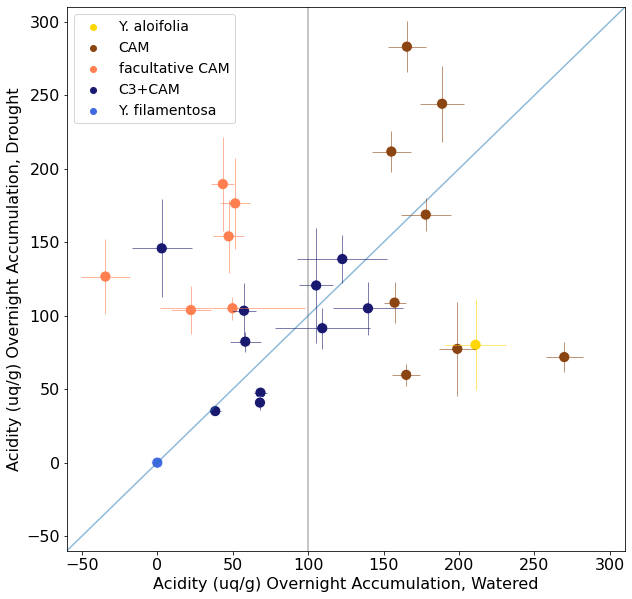

In [103]:
# plot the data by physiological category (based on TA data)
fig,ax = plt.subplots(figsize=(10,10))
ax.axvline(x=100,color="dimgray",alpha=0.5)
#ax.axhline(y=0,color="dimgray",alpha=0.5)
sns.lineplot(x=np.arange(-60,311,10),y=np.arange(-60,311,10),color="tab:blue",alpha=0.5)

sns.scatterplot(data=plot,x="Accumulation_W",y="Accumulation_D",hue="CAM physiology",palette=cpal3,s=125)
plt.errorbar(plot["Accumulation_W"],plot["Accumulation_D"],xerr=plot["SE_W"],yerr=plot["SE_D"],
              fmt="o",alpha=0.75,ecolor=plot["physcolor2"],markersize=0,elinewidth=0.75)

ax.tick_params(which="both",labelsize=16)
ax.set_xlim(-60,310)
ax.set_ylim(-60,310)

# reordering the labels
handles, labels = plt.gca().get_legend_handles_labels()

# specify order
order = [0, 3, 1, 2, 4]

# pass handle & labels lists along with order as below
plt.legend([handles[i] for i in order], [labels[i] for i in order],fontsize=14)

plt.xlabel("Acidity (uq/g) Overnight Accumulation, Watered",fontsize=16)
plt.ylabel("Acidity (uq/g) Overnight Accumulation, Drought",fontsize=16)
plt.savefig("./TA_accumulation_byphysTA.png",dpi=300,bbox_inches="tight")
plt.savefig("./TA_accumulation_byphysTA.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./TA_accumulation_byphysTA.svg",dpi=300,bbox_inches="tight")